DATASET SHAPE
(5001, 8)

MISSING VALUES
long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

DUPLICATE VALUES
1768

FIRST 5 ROWS
   long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0          1               11.8                 6.1          1          0   
1          0               14.0                 5.4          0          0   
2          0               11.8                 6.3          1          1   
3          0               14.4                 6.1          0          1   
4          1               13.5                 5.9          0          0   

   lips_thin  distance_nose_to_lip_long  gender  
0          1                          1    Male  
1          1                          0  Female  
2          1                          1    Male  

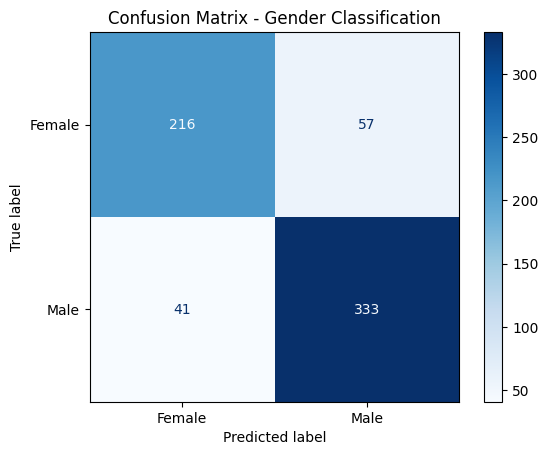


PREDICTED TABLE
      forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
2541               13.2                 5.5          1          1   
3939               15.3                 5.1          1          1   
1194               11.5                 5.4          0          0   
328                13.2                 5.7          0          0   
3456               12.4                 5.9          0          1   
112                13.1                 6.6          1          0   
3002               13.7                 6.4          0          1   
3013               13.6                 6.2          0          1   
3906               11.4                 6.3          1          1   
908                12.4                 5.3          0          1   
262                13.4                 7.0          1          1   
248                14.0                 5.9          1          1   
776                12.2                 5.8          1          0   
4927             

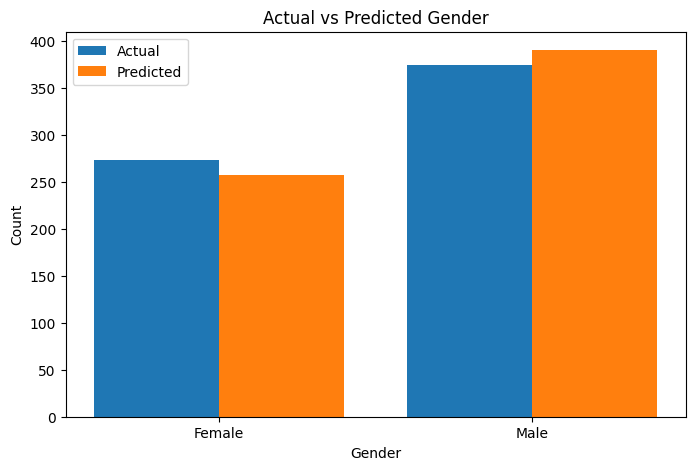


EXTERNAL PREDICTION RESULT
Predicted Gender: Male


In [8]:
# ============================================
# LOGISTIC REGRESSION - GENDER CLASSIFICATION
# ============================================

# Import Libraries
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("gender_classification.csv")

# ============================================
# DATASET INFORMATION
# ============================================

print("DATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE VALUES")
print(df.duplicated().sum())

print("\nFIRST 5 ROWS")
print(df.head())

# ============================================
# PREPROCESSING
# ============================================

# Select Features and Target
df = df[[
    "forehead_width_cm",
    "forehead_height_cm",
    "nose_wide",
    "nose_long",
    "gender"
]]

# Remove Duplicate Rows
df = df.drop_duplicates()

# Encode Gender Column
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])

# Female = 0
# Male = 1

# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop("gender", axis=1)

y = df["gender"]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTRAIN DATA SHAPE:", X_train.shape)
print("TEST DATA SHAPE:", X_test.shape)

# ============================================
# CREATE MODEL
# ============================================

log_reg = LogisticRegression()

# ============================================
# TRAIN MODEL
# ============================================

log_reg.fit(X_train, y_train)

# ============================================
# PREDICTION
# ============================================

y_pred = log_reg.predict(X_test)

# ============================================
# ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nACCURACY SCORE")
print(accuracy)

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Female", "Male"]
    )
)

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Female", "Male"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Gender Classification")

plt.show()

# ============================================
# PREDICTED TABLE
# ============================================

predicted_table = X_test.copy()

predicted_table["Actual_Gender"] = y_test.values

predicted_table["Predicted_Gender"] = y_pred

# Convert Numeric Values to Labels
predicted_table["Actual_Gender"] = le.inverse_transform(
    predicted_table["Actual_Gender"]
)

predicted_table["Predicted_Gender"] = le.inverse_transform(
    predicted_table["Predicted_Gender"]
)

print("\nPREDICTED TABLE")

print(predicted_table.head(20))

# ============================================
# SAVE PREDICTED TABLE
# ============================================

predicted_table.to_csv("predicted_output.csv", index=False)

print("\nPredicted table saved successfully!")

# ============================================
# BAR CHART
# ============================================

actual_counts = predicted_table["Actual_Gender"].value_counts()

predicted_counts = predicted_table["Predicted_Gender"].value_counts()

labels = ["Female", "Male"]

x = range(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x, actual_counts[labels], width=0.4, label="Actual")

plt.bar(
    [i + 0.4 for i in x],
    predicted_counts[labels],
    width=0.4,
    label="Predicted"
)

plt.xticks([i + 0.2 for i in x], labels)

plt.xlabel("Gender")

plt.ylabel("Count")

plt.title("Actual vs Predicted Gender")

plt.legend()

plt.show()

# ============================================
# EXTERNAL PREDICTION
# ============================================

new_data = [[13.5, 6.2, 1, 1]]

new_df = pd.DataFrame(
    new_data,
    columns=X.columns
)

result = log_reg.predict(new_df)[0]

print("\nEXTERNAL PREDICTION RESULT")

print(
    "Predicted Gender:",
    le.inverse_transform([result])[0]
)